# Diagrama UML
Un diagrama UML de base de datos es la representación visual de un esquema de base de datos utilizando el Lenguaje Unificado de Modelado (UML). Permite diseñar, documentar y comunicar la estructura lógica de los datos y sus relaciones de forma estandarizada antes de su implementación

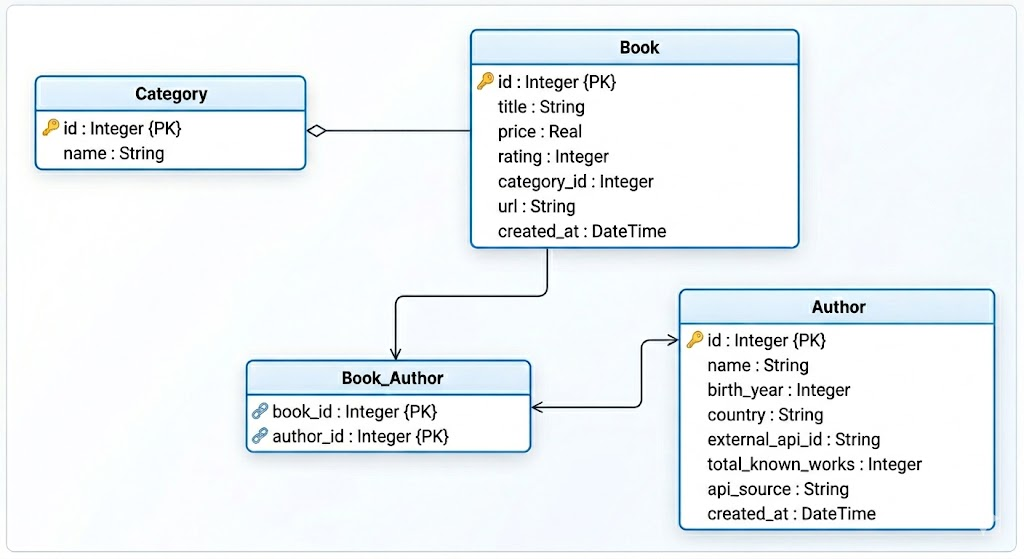

# Imports de las librerías

In [1]:
# Imports de las librerías
import sqlite3
from bs4 import BeautifulSoup
import requests
import time
import re
from urllib.parse import urljoin

# Conexión inicial a la BD (SQLite como DBMS)

In [2]:
# Conexión inicial a la BD
connection = sqlite3.connect("pengu_books.db")
cursor = connection.cursor()
cursor.execute("PRAGMA foreign_keys = ON")
print("Se realiza la conexión a la BD pengu_books")

Se realiza la conexión a la BD pengu_books


# Se crean las tablas
1) categories
2) authors
3) books
4) book_author


In [3]:
# FK activadas manualmente
cursor.execute("PRAGMA foreign_keys = ON")

# Tabla de categories
cursor.execute("""
    CREATE TABLE IF NOT EXISTS categories (
        id      INTEGER PRIMARY KEY AUTOINCREMENT,
        name    TEXT UNIQUE   NOT NULL
    )
""")

# Table de authors
cursor.execute("""
    CREATE TABLE IF NOT EXISTS authors (
        id                INTEGER PRIMARY KEY AUTOINCREMENT,
        name              TEXT    NOT NULL,
        birth_year        INTEGER,
        country           TEXT,
        external_api_id   TEXT    UNIQUE,
        total_known_works INTEGER,
        api_source        TEXT,
        created_at        DATETIME DEFAULT CURRENT_TIMESTAMP
    )
""")

# Tabla de books
cursor.execute("""
    CREATE TABLE IF NOT EXISTS books (
        id          INTEGER PRIMARY KEY AUTOINCREMENT,
        title       TEXT    NOT NULL,
        price       REAL    NOT NULL CHECK (price >= 0),
        rating      INTEGER NOT NULL CHECK (rating >= 1 AND rating <= 5),
        category_id INTEGER NOT NULL,
        url         TEXT UNIQUE,
        created_at  DATETIME DEFAULT CURRENT_TIMESTAMP,
        FOREIGN KEY (category_id) REFERENCES categories(id)
    )
""")

# Tabla book_author (tabla puente N:M) 
cursor.execute("""
    CREATE TABLE IF NOT EXISTS book_author (
        book_id   INTEGER NOT NULL,
        author_id INTEGER NOT NULL,
        PRIMARY KEY (book_id, author_id),
        FOREIGN KEY (book_id)   REFERENCES books(id)   ON DELETE CASCADE,
        FOREIGN KEY (author_id) REFERENCES authors(id) ON DELETE CASCADE
    )
""")

# Limpieza idempotente: si el notebook se ejecuto antes, elimina duplicados por URL
cursor.execute("""
    DELETE FROM books
    WHERE url IS NOT NULL
      AND id NOT IN (
          SELECT MIN(id)
          FROM books
          WHERE url IS NOT NULL
          GROUP BY url
      )
""")
cursor.execute("CREATE UNIQUE INDEX IF NOT EXISTS idx_books_url_unique ON books(url)")

connection.commit()
connection.close()
print("Base de datos creada: pengu_books.db")

Base de datos creada: pengu_books.db


# Reconexión a la BD

In [4]:
# Conexión a la BD
connection = sqlite3.connect("pengu_books.db")
cursor = connection.cursor()
cursor.execute("PRAGMA foreign_keys = ON")
print("Se realiza la reconexión a la BD pengu_books")

Se realiza la reconexión a la BD pengu_books


# Checking de la página "Books to Scrape"
Es un bloque de verificación de conexión hacia la página web

In [5]:
# Checking rápido si responde la página de Books to Scrape

try:
    # Indicamos la URL 
    url_books_to_scrape = "https://books.toscrape.com/"

    # Se guarda la respuesta del método GET en la variable response
    url_response = requests.get(url_books_to_scrape, timeout=10)

    # Verificación del estado de conexión
    if url_response.status_code == 200:
        print("Conexión exitosa. La página Books to Scrape responde")

except (Exception,KeyboardInterrupt) as error:
    print(f"Hubo un error {error}")

Conexión exitosa. La página Books to Scrape responde


# Extracción de las categorías
Este bloque de código realiza un proceso de ETL, diseñado para recolectar las categorías de libros de una página web.

In [6]:
# Se inicia extrayendo inicialmente las categorías de los libros
URL = "https://books.toscrape.com/"
response = requests.get(URL, timeout=10)
response.raise_for_status()
sopa = BeautifulSoup(response.text, "html.parser")

# Capturar la lista del panel lateral 
# Scrappeo y extracción a partir de los elementos enlistados luego del <ul>
lista_categorias = sopa.find("ul", class_="nav nav-list").find("li").find_all("li")

# Procesamiento con el bucle for y limpieza/filtro con el strip
categorias_data = []
for categoria in lista_categorias:          
    nombre = categoria.text.strip()
    link = URL + categoria.a["href"]
    categorias_data.append((nombre, link))

# Insert/Carga en la BD
cursor.executemany("INSERT OR IGNORE INTO categories (name) VALUES (?)", [(c[0],) for c in categorias_data])
connection.commit()

# Caché de mapeo id ↔ nombre
cursor.execute("SELECT id, name FROM categories")

# Se crea un diccionario utilizando el nombre de la categoría y el ID
categorias_db = {row[1]: row[0] for row in cursor.fetchall()}

print(f"{len(categorias_db)} categorías guardadas")


50 categorías guardadas


# Extracción de libros
Este bloque se encarga de extraer todos los libros de cada una de las categorías que se guardaron en el bloque anterior.  
Aquí se busca si hay un botón de "Siguiente" para iterar a la siguiente página hasta que extrae todos los libros de esa categoría.

In [7]:
# Preparación de variables - Indicamos los ratings STR con sus contrapartes en INT
rating = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}
libros = []

# Función de scrappeo por categoría
def scrappear_categoria(nombre_categoria, url_categoria, id_categoria):
    libros_scrappeados = []
    url_actual = url_categoria

    # Paginación con el bucle while, bajo la condición de url_actual tiene valores para seguir iterando
    while url_actual:
        response = requests.get(url_actual, timeout=10)
        response.raise_for_status()
        sopa_categoria = BeautifulSoup(response.text, "html.parser") 
        articulos = sopa_categoria.find_all("article", class_="product_pod") # --> De product_pod se obtienen los libros 

        # Limpieza y extracción de los datos del libro
        for articulo in articulos:                                              
            titulo = articulo.h3.a["title"].strip() # --> Limpieza del título
            precio = articulo.find("p", class_="price_color").text 
            precio = float(re.sub(r"[^0-9.]", "", precio)) # --> Limpieza del precio
            class_rating = articulo.find("p", class_="star-rating")["class"][1] 
            estrellas = rating.get(class_rating, 0) # --> Toma el diccionario rating y utiliza la variable "class_rating" definida 1 línea arriba para obtener el valor, el 0 se autocompleta en casos de error. 

            # Construcción de la URL del libro
            link_relativo = articulo.h3.a["href"]
            url_libro = urljoin(url_actual, link_relativo)

            libros_scrappeados.append((titulo, precio, estrellas, id_categoria, url_libro))  

        boton_siguiente = sopa_categoria.find("li", class_="next")              
        if boton_siguiente:
            url_actual = url_actual.rsplit("/", 1)[0] + "/" + boton_siguiente.a["href"]
        else:
            url_actual = None

    return libros_scrappeados

print("Extrayendo las categorías")
tiempo_inicial = time.time()

for nombre, url in categorias_data:
    id_categoria = categorias_db[nombre]
    libros_de_cada_categoria = scrappear_categoria(nombre, url, id_categoria)
    libros.extend(libros_de_cada_categoria) # fusiona las listas 

# Asegura que el upsert funcione aunque esta celda se ejecute despues de una BD previa
cursor.execute("""
    DELETE FROM books
    WHERE url IS NOT NULL
      AND id NOT IN (
          SELECT MIN(id)
          FROM books
          WHERE url IS NOT NULL
          GROUP BY url
      )
""")
cursor.execute("CREATE UNIQUE INDEX IF NOT EXISTS idx_books_url_unique ON books(url)")

# Inserción masiva en SQLite
cursor.executemany("""
    INSERT INTO books (title, price, rating, category_id, url)
    VALUES (?, ?, ?, ?, ?)
    ON CONFLICT(url) DO UPDATE SET
        title = excluded.title,
        price = excluded.price,
        rating = excluded.rating,
        category_id = excluded.category_id
""", libros)
connection.commit()
cursor.execute("SELECT COUNT(*) FROM books")
total_libros_db = cursor.fetchone()[0]

tiempo_final = time.time()                                                      
print(f"{len(libros)} libros extraídos")
print(f"{total_libros_db} libros unicos guardados en la BD")
print(f"El tiempo de inserción fue de {round(tiempo_final - tiempo_inicial)} segundos")

Extrayendo las categorías
1000 libros extraídos
1000 libros unicos guardados en la BD
El tiempo de inserción fue de 62 segundos


# Testeo de la API
Este bloque es un bloque de prueba y testeo.  
Toma el título de un libro y lo "limpia", utiliza ese título para buscar el autor del libro con la API de Open Library.  

Si la página tarda mucho, si el libro no existe en el catálogo o si hay inconvenientes con la conexión --> indicará un error.

In [8]:
# Archivo de testeo de la API

titulo_ejemplo = "Hai to Gensou no Grimgar, Vol. 01 (Hai to Gensou no Grimgar #1)"

# Recorte y limpieza del nombre (sin los paréntesis)
titulo_ejemplo_limpio = re.sub(r'\(.*?\)', '', titulo_ejemplo).strip()
print(f"Obra: {titulo_ejemplo}")
print(f"Título largo: {titulo_ejemplo}")
print(f"Título limpio:{titulo_ejemplo_limpio}\n")

# Simulando una búsqueda con datos inexistentes
print("--- Conexión a open library ---")
url_busqueda_prueba = "https://openlibrary.org/search.json"
parametros = {
    "title": titulo_ejemplo_limpio, 
    "limit": 1, 
    "fields": "title,author_name,author_key"
}

tiempo_prueba_inicial = time.time()

# Bloque de Try-Except en el cual se indica con el timeout que se cancele la petición si no responde en dicho tiempo
try:
    respuesta_ol = requests.get(url_busqueda_prueba, params=parametros, timeout=10)
    datos_ol = respuesta_ol.json()
    
    # Extracción de la información
    if datos_ol.get("docs"):
        doc = datos_ol["docs"][0]

        # Extracción con valores por defecto
        nombre_autor = doc.get("author_name", ["desconocido"])[0]
        id_autor = doc.get("author_key",  ["sin_id"])[0]
        
        print(f"autor encontrado: {nombre_autor}")
        print(f"id externo api:   {id_autor}")
        print("\njson devuelto por open library (fragmento):")
        print(doc)
    else:
        print("La Api no encontró el libro, incluso con el nombre recortado y limpio.")
        
except Exception as e:
    print(f"error en la búsqueda: {e}")

tiempo_prueba_final = time.time()

# Para tener un estimado de cuánto podría tardar con volúmenes altos
print(f"\nTiempo de consulta: {round(tiempo_prueba_final - tiempo_prueba_inicial, 3)} segundos")

Obra: Hai to Gensou no Grimgar, Vol. 01 (Hai to Gensou no Grimgar #1)
Título largo: Hai to Gensou no Grimgar, Vol. 01 (Hai to Gensou no Grimgar #1)
Título limpio:Hai to Gensou no Grimgar, Vol. 01

--- Conexión a open library ---
La Api no encontró el libro, incluso con el nombre recortado y limpio.

Tiempo de consulta: 11.233 segundos


# Enriquecimiento vía API
Pipeline secuencial de 3 fases donde se "enriquece" la BD  
  
Toma los libros que ya se tienen, busca los autores de cada uno usando la API de Open Library.
Luego, toma esos autores y los busca en Wikipedia para pasar por la biografía y deducir de qué países son en función a gentilicios o el país.
Finalmente se carga la información en la BD de SQLite.  

Se utiliza la memoria caché para no estar buscando al mismo autor 2 veces, se incluye un User-Agent para no ser bloqueado por los servidores y se respetan los rate limits usando time.sleep

In [ ]:
# ── pipeline secuencial

mapeo_paises = {
    "american": "USA", 
    "british": "UK", 
    "english": "UK", 
    "scottish": "UK",
    "welsh": "UK", 
    "irish": "Ireland", 
    "french": "France", 
    "spanish": "Spain",
    "german": "Germany", 
    "italian": "Italy", 
    "canadian": "Canada",
    "australian": "Australia", 
    "japanese": "Japan", 
    "russian": "Russia",
    "chinese": "China", 
    "mexican": "Mexico", 
    "argentine": "Argentina",
    "colombian": "Colombia", 
    "chilean": "Chile", 
    "brazilian": "Brazil",
    "indian": "India", 
    "swedish": "Sweden", 
    "norwegian": "Norway",
    "dutch": "Netherlands"
}

# identificador para la API, normalmente bloque las peticiones de python por seguridad
headers = {"User-Agent": "BooksScraperBot/1.0 (estudio_academico@ejemplo.com)"}
cache_autores = {}
session = requests.Session()
session.headers.update(headers)

def limpiar_titulo_para_api(titulo):
    titulo = re.sub(r'\(.*?\)', '', titulo)
    titulo = re.sub(r'\s+', ' ', titulo)
    return titulo.strip(' -:')

def consultar_json(url, params=None, timeout=10, intentos=3):
    for intento in range(intentos):
        try:
            res = session.get(url, params=params, timeout=timeout)
            if res.status_code == 429 and intento < intentos - 1:
                time.sleep(2 + intento)
                continue
            if not res.ok or not res.text.strip():
                return None
            return res.json()
        except (requests.RequestException, ValueError):
            if intento == intentos - 1:
                return None
            time.sleep(1 + intento)
    return None

# ─── fase 1 openlibrary
def buscar_en_openlibrary(book_id, titulo_original):
    """busca autor en open library de forma secuencial."""
    titulo_limpio = limpiar_titulo_para_api(titulo_original)

    datos = {
        "name": "Unknown", "birth_year": None, "country": None,
        "external_api_id": None, "total_known_works": None,
        "api_source": "not_found"
    }

    try:
        # intento 1: titulo limpio; intento 2: sin subtitulo; intento 3: busqueda general
        params_base = {"limit": 3, "fields": "title,author_name,author_key"}
        consultas = [("title", titulo_limpio)]
        if ":" in titulo_limpio:
            consultas.append(("title", titulo_limpio.split(":")[0].strip()))
        consultas.append(("q", titulo_limpio))

        docs = []
        for campo, valor in consultas:
            if not valor:
                continue
            params = {**params_base, campo: valor}
            json_busqueda = consultar_json("https://openlibrary.org/search.json", params=params)
            if json_busqueda and json_busqueda.get("docs"):
                docs = json_busqueda["docs"]
                break

        if not docs:
            return (book_id, datos)

        # consulta de author_key y name
        doc = next((d for d in docs if d.get("author_key") and d.get("author_name")), None)
        if not doc:
            return (book_id, datos)
        author_key  = doc.get("author_key",  [None])[0]
        author_name = doc.get("author_name", [None])[0]

        if not author_key or not author_name:
            return (book_id, datos)

        # cache, si ya se proceso este autor, reutilizar para ahorrar tiempo
        if author_key in cache_autores:
            return (book_id, cache_autores[author_key])

        datos["name"]            = author_name
        datos["external_api_id"] = author_key
        datos["api_source"]      = "open_library+wikipedia"

        # detalles del autor
        clean_key = author_key.replace("/authors/", "")
        autor_json = consultar_json(f"https://openlibrary.org/authors/{clean_key}.json")

        #extraer fecha de nacimiento
        if autor_json:
            birth_raw = autor_json.get("birth_date", "")
            if birth_raw:
                match = re.search(r"\b(1[0-9]{3}|20[0-2][0-9])\b", birth_raw)
                datos["birth_year"] = int(match.group(1)) if match else None


        #consultar resto de sus obras
        obras_json = consultar_json(f"https://openlibrary.org/authors/{clean_key}/works.json", params={"limit": 0})
        
        if obras_json:
            datos["total_known_works"] = obras_json.get("size", None)

        # guardar el resultado exitoso en el cache global
        cache_autores[author_key] = datos
        return (book_id, datos)

    except Exception as e:
        datos["api_source"] = f"error_ol: {str(e)[:20]}"
        return (book_id, datos)


# guardar todos los libros para procesarlos
cursor.execute("SELECT id, title FROM books ORDER BY id")
libros_db = cursor.fetchall()
total_libros = len(libros_db)
resultados_ol = []

print("── fase 1: open library secuencial")
t1 = time.time()

#bucle de procesar cada libro y buscar su autor
for i, libro in enumerate(libros_db, 1):
    resultado = buscar_en_openlibrary(libro[0], libro[1])
    resultados_ol.append(resultado)
    if i % 50 == 0 or i == total_libros:
        print(f"  {i}/{total_libros} libros procesados...")

print(f"ok -> open library completado en {round(time.time()-t1, 2)}s")
encontrados = sum(1 for _, d in resultados_ol if d["external_api_id"])
print(f"  autores encontrados: {encontrados}/{total_libros}")


# ─── fase 2: wikipedia secuencial

print("\n── fase 2: wikipedia secuencial ───────")
t2 = time.time()

# filtro: solo los que tienen id oficial de open library y nombre real
# almacenar solo datos de autores que no se repiten para las consultas de pais
autores_unicos = {}
for book_id, datos in resultados_ol:
    key = datos.get("external_api_id")
    if key and key not in autores_unicos and datos["name"] != "Unknown":
        autores_unicos[key] = datos

print(f"  autores unicos a consultar en wikipedia: {len(autores_unicos)}")

#consultar los autores en wikipedia para obtener sus paises
for i, (author_key, datos) in enumerate(autores_unicos.items(), 1):
    if i % 50 == 0 or i == len(autores_unicos):
        print(f"  {i}/{len(autores_unicos)} autores procesados...")

    try:
        # rest_v1 y quote para evitar errores de codificacion en las url
        # quote es para utilizar formato de web en espavios
        url = f"https://en.wikipedia.org/api/rest_v1/page/summary/{requests.utils.quote(datos['name'])}"
        wiki_json = consultar_json(url)

        if wiki_json:
            
            # extraer descripcion para buscar si hace referencia a un pais
            texto = (wiki_json.get("description", "") + " " + wiki_json.get("extract", "")).lower()

            for gentilicio, pais in mapeo_paises.items():
                if re.search(rf'\b{gentilicio}\b', texto):
                    datos["country"] = pais
                    # actualizacion de la memoria
                    cache_autores.setdefault(author_key, datos)["country"] = pais
                    break

    except Exception:
        pass

    # respeto al rate limit de la api
    time.sleep(0.8)  

print(f"ok -> wikipedia completado en {round(time.time()-t2, 2)}s")


# ─── fase 3: inyeccion segura en sqlite
print("\n── fase 3: inyectando en sqlite ────────────────────────────")

autores_guardados = set()
relaciones_guardadas = 0

for book_id, info in resultados_ol:
    # Si no hay id externo confiable, no se inserta Unknown para evitar autores duplicados
    if not info["external_api_id"]:
        continue

    cursor.execute("""
        INSERT INTO authors
            (name, birth_year, country, external_api_id, total_known_works, api_source)
        VALUES (?, ?, ?, ?, ?, ?)
        ON CONFLICT(external_api_id) DO UPDATE SET
            name = excluded.name,
            birth_year = COALESCE(excluded.birth_year, authors.birth_year),
            country = COALESCE(excluded.country, authors.country),
            total_known_works = COALESCE(excluded.total_known_works, authors.total_known_works),
            api_source = excluded.api_source
    """, (info["name"], info["birth_year"], info["country"],
          info["external_api_id"], info["total_known_works"], info["api_source"]))
    autores_guardados.add(info["external_api_id"])

    cursor.execute("SELECT id FROM authors WHERE external_api_id = ?", (info["external_api_id"],))
    fila = cursor.fetchone()
    if fila:
        cursor.execute("INSERT OR IGNORE INTO book_author (book_id, author_id) VALUES (?, ?)", (book_id, fila[0]))
        relaciones_guardadas += cursor.rowcount

connection.commit()
print(f"autores insertados/actualizados: {len(autores_guardados)}")
print(f"relaciones nuevas libro-autor: {relaciones_guardadas}")

── fase 1: open library secuencial
  50/1000 libros procesados...
  100/1000 libros procesados...
  150/1000 libros procesados...
  200/1000 libros procesados...
  250/1000 libros procesados...
  300/1000 libros procesados...
  350/1000 libros procesados...
  400/1000 libros procesados...
  450/1000 libros procesados...
  500/1000 libros procesados...
  550/1000 libros procesados...
  600/1000 libros procesados...
  650/1000 libros procesados...
  700/1000 libros procesados...
  750/1000 libros procesados...
  800/1000 libros procesados...
  850/1000 libros procesados...
  900/1000 libros procesados...
  950/1000 libros procesados...
  1000/1000 libros procesados...
ok -> open library completado en 1397.29s
  autores encontrados: 973/1000

── fase 2: wikipedia secuencial ───────
  autores unicos a consultar en wikipedia: 805
  50/805 autores procesados...
  100/805 autores procesados...
  150/805 autores procesados...
  200/805 autores procesados...
  250/805 autores procesados...
  30

# Creación de índices de rendimiento

In [10]:
# ── Índices de rendimiento

# Índices para claves foráneas
cursor.execute("CREATE UNIQUE INDEX IF NOT EXISTS idx_books_url_unique ON books(url)")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_books_category_id ON books(category_id)")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_book_author_author_id ON book_author(author_id)")

# Índices para consultas analíticas, where, group by, order by etc
cursor.execute("CREATE INDEX IF NOT EXISTS idx_books_rating_price ON books(rating, price)")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_authors_name ON authors(name)")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_authors_country ON authors(country)")
connection.commit()

# Consultas SQL

In [11]:
connection = sqlite3.connect("pengu_books.db")
cursor = connection.cursor()
cursor.execute("PRAGMA foreign_keys = ON")

# Función auxiliar para imprimir los resultados
def imprimir_consulta(titulo, query):
    print(f"\n{titulo}")
    cursor.execute(query)
    for fila in cursor.fetchall():
        print(fila)

# Libros con más de 3 estrellas por menos de £10
imprimir_consulta(
    "1. Libros con más de 3 estrellas por menos de £10 (rating > 3 y precio < 10)",
    """
    SELECT title, price, rating 
    FROM books 
    WHERE rating > 3 AND price < 10.0 
    ORDER BY price ASC 
    LIMIT 5;
    """
)

# Autor con peor promedio de rating (mínimo 5 libros)
imprimir_consulta(
    "2. Autor con peor promedio de rating (mínimo 5 libros)",
    """
    SELECT a.name, ROUND(AVG(b.rating), 2) as avg_rating, COUNT(b.id) as total_books 
    FROM authors a 
    JOIN book_author ba ON a.id = ba.author_id 
    JOIN books b ON ba.book_id = b.id 
    GROUP BY a.id 
    HAVING total_books >= 5 
    ORDER BY avg_rating ASC 
    LIMIT 5;
    """
)

# Categoría con mayor precio promedio
imprimir_consulta(
    "3. Categoría con mayor precio promedio",
    """
    SELECT c.name, ROUND(AVG(b.price), 2) as avg_price 
    FROM categories c 
    JOIN books b ON c.id = b.category_id 
    GROUP BY c.id 
    ORDER BY avg_price DESC 
    LIMIT 5;
    """
)

# Top 5 autores con más libros
imprimir_consulta(
    "4. Top 5 autores con más libros",
    """
    SELECT a.name, COUNT(b.id) as total_books 
    FROM authors a 
    JOIN book_author ba ON a.id = ba.author_id 
    JOIN books b ON ba.book_id = b.id 
    WHERE a.name != "Unknown"
    GROUP BY a.id 
    ORDER BY total_books DESC 
    LIMIT 5;
    """
)

# ¿Qué país produce más libros con rating mayor a 3 estrellas?
imprimir_consulta(
    "5. ¿Qué país produce más libros con rating mayor a 3 estrellas?",
    """
    SELECT a.country, COUNT(b.id) as high_rated_books 
    FROM authors a 
    JOIN book_author ba ON a.id = ba.author_id 
    JOIN books b ON ba.book_id = b.id 
    WHERE b.rating > 3 AND a.country IS NOT NULL 
    GROUP BY a.country 
    ORDER BY high_rated_books DESC 
    LIMIT 5;
    """
)

# Prueba de indexación y performance
print("\n Análisis de performance (búsqueda de texto)")

# Consulta sin índice
query_lenta = "SELECT title, price FROM books WHERE title LIKE '%Silence%'"

# Medición sin índice 
tiempo_inicio_lento = time.time()
for _ in range(100):
    cursor.execute(query_lenta)
    cursor.fetchall()
tiempo_fin_lento = time.time()
tiempo_sin_indice = tiempo_fin_lento - tiempo_inicio_lento

print(f"Tiempo de ejecución sin índice (100 iteraciones): {tiempo_sin_indice:.5f} segundos")

# Creación del índice
print("inyectando indice en la columna 'title'...")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_books_title ON books(title);")
connection.commit()

# Medición con índice
tiempo_inicio_rapido = time.time()
for _ in range(100):
    cursor.execute(query_lenta)
    cursor.fetchall()
tiempo_fin_rapido = time.time()
tiempo_con_indice = tiempo_fin_rapido - tiempo_inicio_rapido

print(f"Tiempo de ejecución con indice (100 iteraciones): {tiempo_con_indice:.5f} segundos")

# Conclusión
mejora = ((tiempo_sin_indice - tiempo_con_indice) / tiempo_sin_indice) * 100 if tiempo_sin_indice > 0 else 0
print(f" Conclusion: La indexacion mejoró la velocidad de busqueda en un {mejora:.1f}%")

connection.close()


1. Libros con más de 3 estrellas por menos de £10 (rating > 3 y precio < 10)

2. Autor con peor promedio de rating (mínimo 5 libros)
('Sophie Kinsella', 2.0, 5)
('Worth Books', 2.3, 10)
('Cassandra Clare', 2.86, 7)
('Stephen King', 2.87, 15)
('高屋奈月', 2.88, 8)

3. Categoría con mayor precio promedio
('Suspense', 58.33)
('Novels', 54.81)
('Politics', 53.61)
('Health', 51.45)
('New Adult', 46.38)

4. Top 5 autores con más libros
('Stephen King', 15)
('Worth Books', 10)
('J.K. Rowling', 9)
('高屋奈月', 8)
('Cassandra Clare', 7)

5. ¿Qué país produce más libros con rating mayor a 3 estrellas?
('USA', 195)
('UK', 48)
('Canada', 6)
('Germany', 4)
('Japan', 3)

 Análisis de performance (búsqueda de texto)
Tiempo de ejecución sin índice (100 iteraciones): 0.01903 segundos
inyectando indice en la columna 'title'...
Tiempo de ejecución con indice (100 iteraciones): 0.01603 segundos
 Conclusion: La indexacion mejoró la velocidad de busqueda en un 15.8%
